In [1]:
print("simpal")

simpal


In [6]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [7]:
data = pd.read_csv(r"C:\Users\DELL\Desktop\Alz\Alzheimer-s-Disease\alzheimers_disease_data.csv")

In [8]:
new_df = data.drop(columns=[
    'PatientID','Gender','Ethnicity','EducationLevel','Smoking',
    'AlcoholConsumption','FamilyHistoryAlzheimers','CardiovascularDisease',
    'Diabetes','Depression','SystolicBP','DiastolicBP','Confusion',
    'Disorientation','DifficultyCompletingTasks','Forgetfulness',
    'DoctorInCharge'
])

X = new_df.drop(columns=['Diagnosis'])
y = new_df['Diagnosis']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [2]:
from catboost import CatBoostClassifier

# Load saved model
model = CatBoostClassifier()
model.load_model("alzheimers_catboost_model.cbm")

CatBoostClassifier(bagging_temperature=0.2, depth=8, iterations=100, l2_leaf_reg=3, learning_rate=0.1, loss_function='Logloss', random_seed=42, random_strength=1, verbose=0)

In [4]:
# !pip install shap

In [5]:
import shap

c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

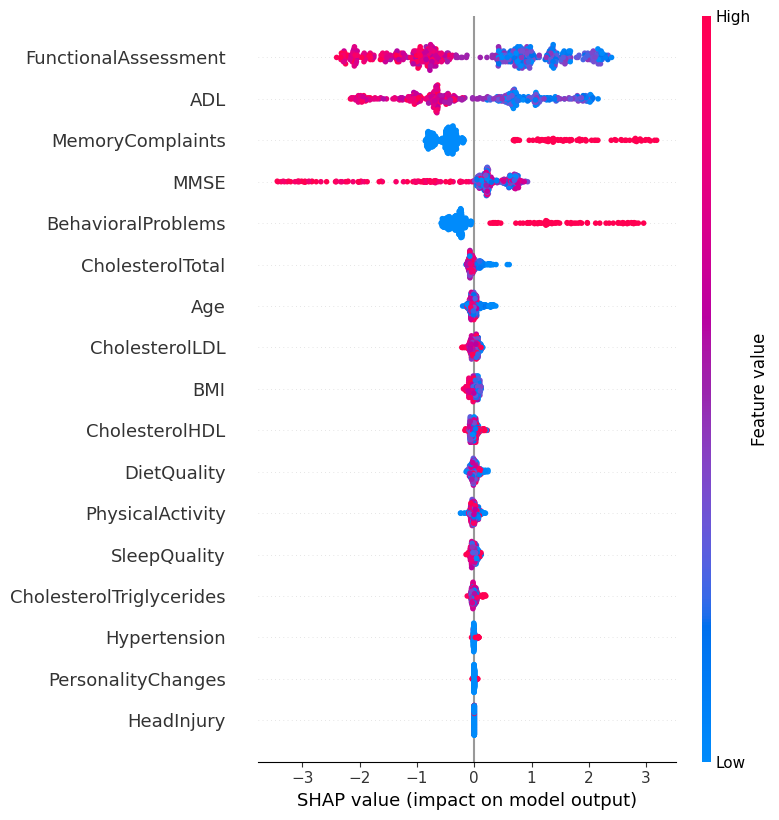

In [10]:
shap.summary_plot(shap_values, X_test)

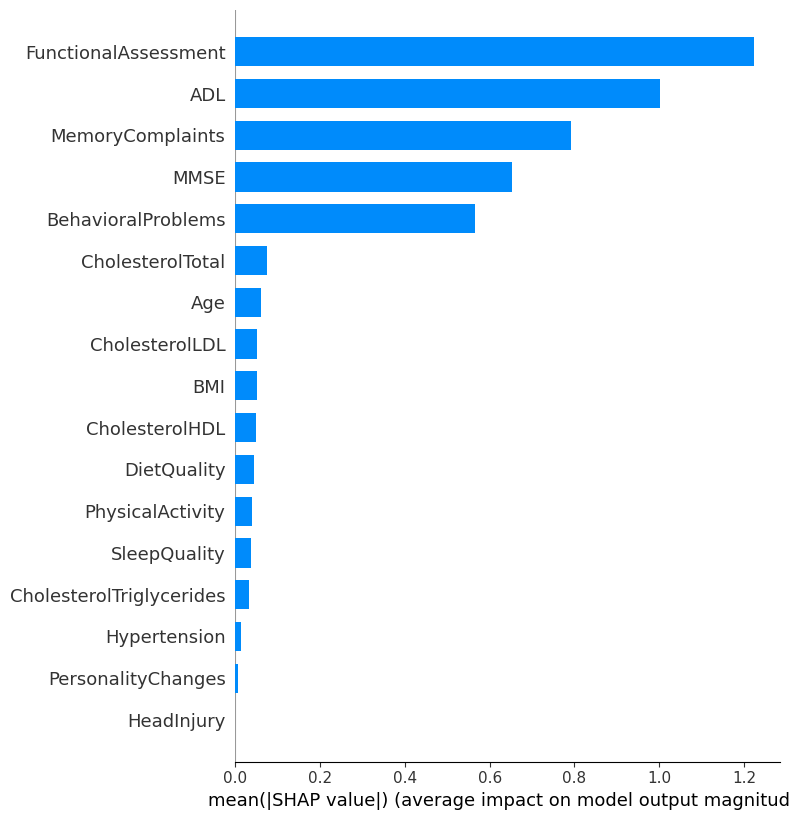

In [11]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

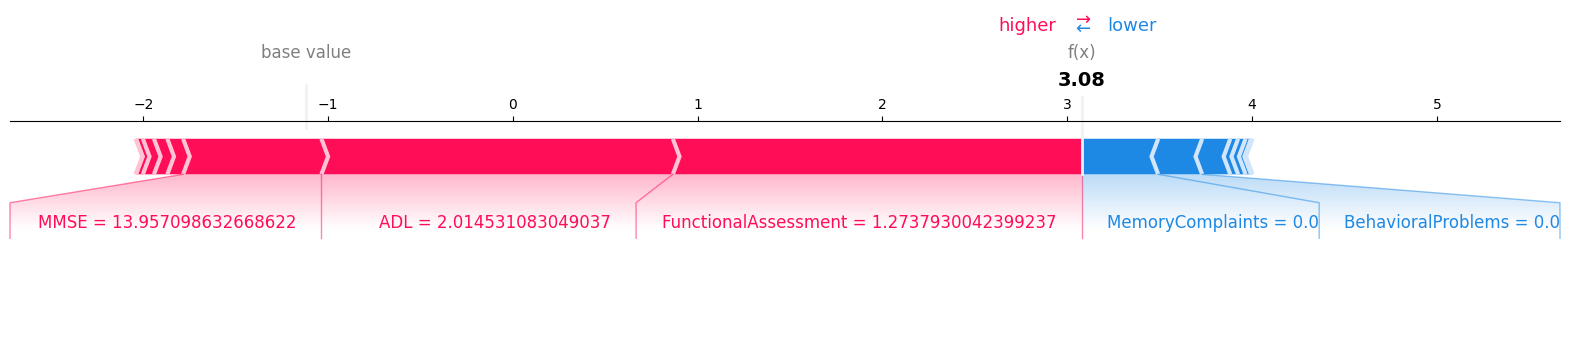

In [15]:
shap.plots.force(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
    matplotlib=True,
    figsize=(20, 3)
)

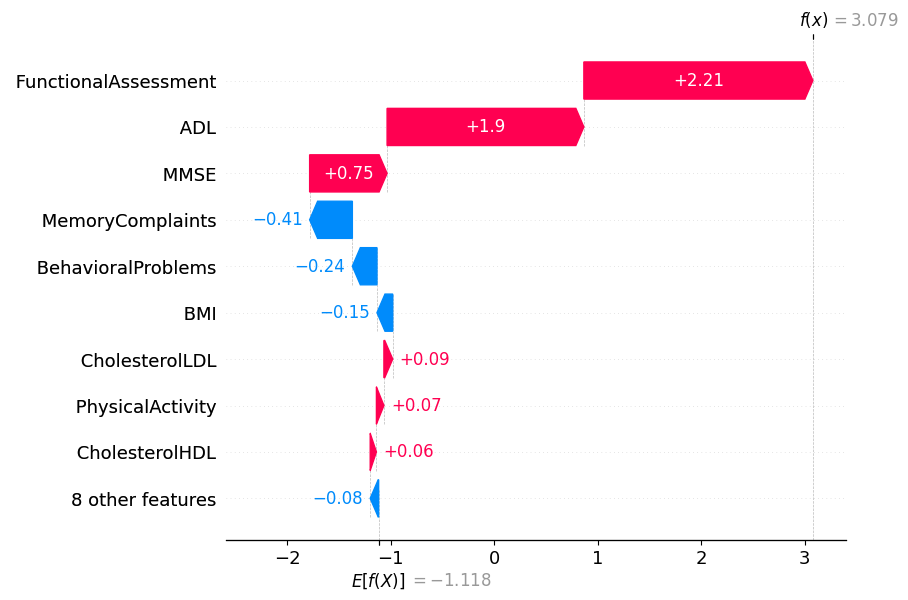

In [13]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

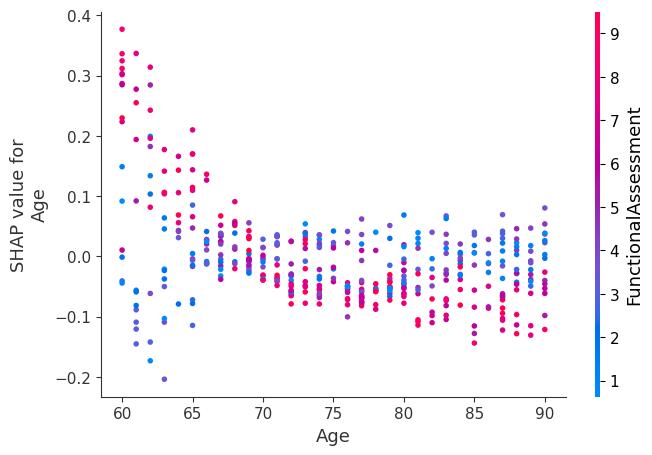

In [14]:
shap.dependence_plot("Age", shap_values, X_test)